In [1]:
# Control-composition sensitivity review (Moore et al. Batch_1)
# Reads only what run_control_composition*.py already wrote to Analysis_Results/Control_Composition/
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from viz_style import apply_style
apply_style()
import config

res = pd.read_csv(config.CTRL_COMP_DIR / 'jaccard_results.csv')
null = pd.read_csv(config.CTRL_COMP_DIR / 'null_distribution.csv')
print(f"tertile rows: {len(res)}, null rows: {len(null)}")
res.head()

tertile rows: 198, null rows: 3600


,jaccard_k25,signflip_k25,jaccard_k50,signflip_k50,jaccard_k100,signflip_k100,jaccard_k200,signflip_k200,jaccard_k500,signflip_k500,spearman,disease,split,axis,draw,tag,layer,n_case,n_ctrl,delta_d
0,0.000000,NaN,0.003367,0.0,0.011810,0.0,0.016994,0.0,0.038521,0.0,0.305712,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,CPM_log1p,72,23.0,2.358629
1,0.000000,NaN,0.006803,0.0,0.016990,0.0,0.023964,0.0,0.043509,0.0,0.304923,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,TPM_log2,72,23.0,2.358629
2,0.000000,NaN,0.000000,NaN,0.006734,0.0,0.012714,0.0,0.035703,0.0,0.312630,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,TMM_log2,72,23.0,2.358629
3,0.006803,0.0,0.010309,0.0,0.013765,0.0,0.026848,0.0,0.050207,0.0,0.351389,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,RUVg_Platelet_k1,72,23.0,2.358629
4,0.000000,NaN,0.000000,NaN,0.015281,0.0,0.023103,0.0,0.046259,0.0,0.367063,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,RUVg_Platelet_k2,72,23.0,2.358629


In [2]:
# 1. null p-value per (disease, layer, axis): how often a size-matched random split
# agrees no better than the bias-stratified split
def null_pvalue(res, null, metric='jaccard_k100'):
    out = []
    for (dis, lay), g in null.groupby(['disease', 'layer']):
        ref = g[metric].values
        for _, r in res[(res.disease == dis) & (res.layer == lay)].iterrows():
            out.append(dict(disease=dis, layer=lay, axis=r['axis'], obs=r[metric],
                            null_mean=float(ref.mean()), null_sd=float(ref.std()),
                            p_lower=float((ref <= r[metric]).mean())))
    return pd.DataFrame(out)

pval = null_pvalue(res, null)
pval.sort_values('p_lower').head(20)

,disease,layer,axis,obs,null_mean,null_sd,p_lower
10,Pancreatic Cancer,CPM_log1p,PC1_bias,0.005025,0.023329,0.005815,0.0
54,Pancreatic Cancer,RUVg_Platelet_k1,PC1_bias,0.005042,0.020579,0.005450,0.0
99,Pancreatitis,CPM_log1p,log(Total Reads),0.005042,0.016057,0.005157,0.0
100,Pancreatitis,CPM_log1p,Spliced Reads (%),0.005042,0.016057,0.005157,0.0
87,Pancreatic Cancer,TMM_log2,PC1_bias,0.003350,0.020098,0.005317,0.0
109,Pancreatitis,CPM_log1p,PC1_bias,0.001675,0.016057,0.005157,0.0
105,Pancreatitis,CPM_log1p,GC Bias,0.005042,0.016057,0.005157,0.0
110,Pancreatitis,Proposed_Full_k1,log(Total Reads),0.000000,0.012523,0.004666,0.0
96,Pancreatic Cancer,TPM_log2,NG80,0.008547,0.025642,0.006303,0.0
98,Pancreatic Cancer,TPM_log2,PC1_bias,0.003350,0.025642,0.006303,0.0


In [3]:
# p_lower = fraction of null (random-split) jaccard_k100 draws <= the observed tertile value,
# per (disease, layer); low p_lower = tertile reproduces WORSE than a same-size random split.
print(f"null baseline jaccard@100: mean={null['jaccard_k100'].mean():.3f}, "
     f"sd={null['jaccard_k100'].std():.3f}  (tier 1 floor, axis-independent)")
print(f"tertile vs null: median p_lower={pval['p_lower'].median():.3f}, "
     f"{(pval['p_lower'] < 0.05).mean()*100:.0f}% of (disease,layer,axis) significantly BELOW null, "
     f"{(pval['p_lower'] > 0.95).mean()*100:.0f}% significantly ABOVE null")

by_axis = pval.groupby('axis')['p_lower'].agg(
    median_p_lower='median',
    frac_sig_worse=lambda s: (s < 0.05).mean(),
    frac_sig_better=lambda s: (s > 0.95).mean()).sort_values('median_p_lower')
by_axis['frac_sig_worse'] = (by_axis['frac_sig_worse'] * 100).round(1).astype(str) + '%'
by_axis['frac_sig_better'] = (by_axis['frac_sig_better'] * 100).round(1).astype(str) + '%'
by_axis

null baseline jaccard@100: mean=0.018, sd=0.007  (tier 1 floor, axis-independent)
tertile vs null: median p_lower=0.075, 43% of (disease,layer,axis) significantly BELOW null, 2% significantly ABOVE null


,median_p_lower,frac_sig_worse,frac_sig_better
axis,,,
PC1_bias,0.0025,77.8%,0.0%
NG80,0.0150,66.7%,0.0%
log(Total Reads),0.0175,72.2%,0.0%
Gene Length Bias,0.0550,50.0%,0.0%
GC Bias,0.0550,44.4%,0.0%
gDNA Contamination (Intron/Exon),0.0650,44.4%,0.0%
RNA Degradation (3' Bias),0.1000,27.8%,0.0%
Spliced Reads (%),0.1050,38.9%,0.0%
Platelet Score,0.1175,38.9%,22.2%


In [4]:
# 3. optional deep dive into one comparison's t-statistics / expression matrices
# (written per-comparison by run_control_composition.py; load only what's needed)
tag = 'Pancreatic_Cancer__PC1_bias'
stat_dir = config.CTRL_COMP_STAT_DIR / tag
t0 = pd.read_csv(stat_dir / 'T0_welch_t.csv.gz', index_col=0)
t2 = pd.read_csv(stat_dir / 'T2_welch_t.csv.gz', index_col=0)
t0[['CPM_log1p', 'GeneName']].join(t2[['CPM_log1p']], rsuffix='_T2').sort_values('CPM_log1p').head(10)

,CPM_log1p,GeneName,CPM_log1p_T2
ENSG00000107223.14,-3.507659,EDF1,0.407309
ENSG00000124228.16,-3.502703,DDX27,1.032138
ENSG00000114861.25,-3.281962,FOXP1,-2.319043
ENSG00000242028.9,-3.106850,HYPK,0.329804
ENSG00000136802.13,-3.087232,LRRC8A,-2.334358
ENSG00000213741.12,-3.076732,RPS29,0.170255
ENSG00000116251.12,-3.042118,RPL22,0.670042
ENSG00000133106.16,-3.015448,EPSTI1,1.189197
ENSG00000100941.10,-2.949856,PNN,1.648041
ENSG00000142541.19,-2.931174,RPL13A,-0.202351


In [5]:
# DESeq2 arm design selector. run_control_composition_deseq2.py now writes all four;
# flip RUVG_PICK to compare k1 / k2 / k3 without touching anything downstream.
ALL_DESEQ2_DESIGNS = ['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']
RUVG_PICK = 'ruvg_k2'
DESIGNS = ['no_covariate', RUVG_PICK]
print('DESeq2 designs in use:', DESIGNS)

# 4. DESeq2 arm (run_control_composition_deseq2.py): same tags/subsets, Wald `stat` instead
# of Welch t. All four designs (no_covariate, ruvg_k1/k2/k3) and a smaller null (n=30 vs 200) --
# see script docstring for the runtime tradeoff.
d_res = pd.read_csv(config.CTRL_COMP_DIR / 'deseq2_jaccard_results.csv')
d_null = pd.read_csv(config.CTRL_COMP_DIR / 'deseq2_null_distribution.csv')
d_res = d_res[d_res.layer.isin(DESIGNS)]
d_null = d_null[d_null.layer.isin(DESIGNS)]
d_pval = null_pvalue(d_res, d_null)
print(f"tertile rows: {len(d_res)}, null rows: {len(d_null)}")
d_pval.sort_values('p_lower').head(20)

tertile rows: 44, null rows: 120


,disease,layer,axis,obs,null_mean,null_sd,p_lower
1,Pancreatic Cancer,no_covariate,Spliced Reads (%),0.058364,0.086005,0.010683,0.000000
7,Pancreatic Cancer,no_covariate,Gene Length Bias,0.039718,0.086005,0.010683,0.000000
5,Pancreatic Cancer,no_covariate,Platelet Score,0.036317,0.086005,0.010683,0.000000
4,Pancreatic Cancer,no_covariate,RNA Degradation (3' Bias),0.051026,0.086005,0.010683,0.000000
10,Pancreatic Cancer,no_covariate,PC1_bias,0.053537,0.086005,0.010683,0.000000
13,Pancreatic Cancer,ruvg_k2,gDNA Contamination (Intron/Exon),0.119115,0.148169,0.013428,0.000000
8,Pancreatic Cancer,no_covariate,NG80,0.056944,0.086005,0.010683,0.000000
16,Pancreatic Cancer,ruvg_k2,Platelet Score,0.114041,0.148169,0.013428,0.000000
21,Pancreatic Cancer,ruvg_k2,PC1_bias,0.104793,0.148169,0.013428,0.000000
23,Pancreatitis,no_covariate,Spliced Reads (%),0.011845,0.031693,0.008413,0.000000


In [6]:
# same null-vs-tertile test as cell 3, DESeq2 arm (see that cell's comment for how p_lower is defined)
print(f"tertile vs null (DESeq2): median p_lower={d_pval['p_lower'].median():.3f}, "
     f"{(d_pval['p_lower'] < 0.05).mean()*100:.0f}% of (disease,layer,axis) significantly BELOW null, "
     f"{(d_pval['p_lower'] > 0.95).mean()*100:.0f}% significantly ABOVE null")

d_by_axis = d_pval.groupby('axis')['p_lower'].agg(
    median_p_lower='median',
    frac_sig_worse=lambda s: (s < 0.05).mean(),
    frac_sig_better=lambda s: (s > 0.95).mean()).sort_values('median_p_lower')
d_by_axis['frac_sig_worse'] = (d_by_axis['frac_sig_worse'] * 100).round(1).astype(str) + '%'
d_by_axis['frac_sig_better'] = (d_by_axis['frac_sig_better'] * 100).round(1).astype(str) + '%'
d_by_axis

tertile vs null (DESeq2): median p_lower=0.050, 50% of (disease,layer,axis) significantly BELOW null, 5% significantly ABOVE null


,median_p_lower,frac_sig_worse,frac_sig_better
axis,,,
RNA Degradation (3' Bias),0.000000,75.0%,0.0%
PC1_bias,0.000000,75.0%,0.0%
Gene Length Bias,0.016667,75.0%,0.0%
Platelet Score,0.016667,75.0%,0.0%
NG80,0.033333,50.0%,0.0%
log(Total Reads),0.033333,75.0%,0.0%
GC Bias,0.133333,25.0%,0.0%
rRNA Fraction,0.200000,25.0%,0.0%
Spliced Reads (%),0.266667,50.0%,0.0%


# 6. FDR<0.05 reproducibility (gene + pathway level)
Everything above used fixed top-K marker lists. From here on the estimand is what a paper
actually reports: the FDR<0.05 significant set. `gene_fdr_set_jaccard.csv` and
`gsea_split_jaccard/summary*.csv` already carry a matched random-split null (same tags/sizes,
no bias-axis stratification) so no separate null-band construction is needed. Both arms are
restricted to the DESeq2 designs selected in `DESIGNS` (`no_covariate` + `RUVG_PICK`).

In [7]:
PAIRS = [('T0T1', 0, 1), ('T0T2', 0, 2), ('T1T2', 1, 2)]

# gene-level: per-pair (not pre-averaged) FDR<0.05 Jaccard, cache-first
_gene_pair_csv = config.CTRL_COMP_DIR / 'gene_fdr_pairwise.csv'
if _gene_pair_csv.exists():
    fdr_g_pairs = pd.read_csv(_gene_pair_csv)
else:
    sys.path.insert(0, str(Path('control_composition').resolve()))
    from compute_fdr_set_jaccard import sig_sets, STAT_DIR
    rows = []
    for tag in sorted(p.name for p in STAT_DIR.iterdir() if p.is_dir()):
        disease = 'Pancreatic Cancer' if tag.startswith('Pancreatic_Cancer') else 'Pancreatitis'
        kind = 'random' if '__null_' in tag else 'tertile'
        axis = tag.split('__', 1)[1]
        for design in DESIGNS:
            s = sig_sets(tag, design)
            if s is None:
                continue
            for name, i, j in PAIRS:
                a, b = s[i], s[j]
                if not (a | b):
                    continue
                rows.append(dict(tag=tag, disease=disease, kind=kind, axis=axis, design=design,
                                 pair=name, jaccard=len(a & b) / len(a | b)))
    fdr_g_pairs = pd.DataFrame(rows)
    fdr_g_pairs.to_csv(_gene_pair_csv, index=False)

fdr_g_pairs = fdr_g_pairs[fdr_g_pairs.disease == 'Pancreatic Cancer']
g_tert = fdr_g_pairs[fdr_g_pairs.kind == 'tertile']
g_null = fdr_g_pairs[fdr_g_pairs.kind == 'random']

# pathway-level: jacc_T0T1/T0T2/T1T2 already in the GSEA summary, just melt to match
gsea_summary = pd.read_csv(config.CTRL_COMP_DIR / 'gsea_split_jaccard' / 'summary.csv')
gsea_null = pd.read_csv(config.CTRL_COMP_DIR / 'gsea_split_jaccard' / 'summary_null.csv')


def melt_pairs(df):
    df = df[df.method.isin([f'deseq2__{d}' for d in DESIGNS])].copy()
    df['design'] = df.method.str.replace('deseq2__', '', regex=False)
    long = df.melt(id_vars=['tag', 'axis', 'design'], value_vars=['jacc_T0T1', 'jacc_T0T2', 'jacc_T1T2'],
                   var_name='pair', value_name='jaccard')
    long['pair'] = long['pair'].str.replace('jacc_', '', regex=False)
    return long


p_tert = melt_pairs(gsea_summary)
p_null = melt_pairs(gsea_null)

axes = sorted(g_tert.axis.unique())
print(f"axes: {len(axes)}, gene tertile points: {len(g_tert)} (11 axes x 2 designs x 3 pairs), "
     f"gene null points: {len(g_null)}")
print(f"pathway tertile points: {len(p_tert)}, pathway null points: {len(p_null)}")

axes: 11, gene tertile points: 66 (11 axes x 2 designs x 3 pairs), gene null points: 180
pathway tertile points: 66, pathway null points: 60


In [8]:
# p_lower = fraction of random-split null jaccard draws <= the observed tertile median,
# per (axis, design). low p_lower = a bias-stratified split reproduces WORSE than a same-size
# random split -- i.e. the "signal" is indistinguishable from (or worse than) sampling noise.
def fdr_pvalue(tert, null, group_col='design'):
    out = []
    for design, g in null.groupby(group_col):
        ref = g['jaccard'].values
        for (axis, d), r in tert.groupby(['axis', group_col]):
            if d != design:
                continue
            obs = r['jaccard'].median()
            out.append(dict(axis=axis, design=design, obs=obs,
                            null_mean=float(ref.mean()), null_sd=float(ref.std()),
                            p_lower=float((ref <= obs).mean())))
    return pd.DataFrame(out)

g_pval = fdr_pvalue(g_tert, g_null)
p_pval = fdr_pvalue(p_tert, p_null)

for name, pv in [('gene', g_pval), ('pathway', p_pval)]:
    print(f"{name}: median p_lower={pv['p_lower'].median():.3f}, "
         f"{(pv['p_lower'] < 0.05).mean()*100:.0f}% significantly BELOW null, "
         f"{(pv['p_lower'] > 0.95).mean()*100:.0f}% significantly ABOVE null  (n={len(pv)})")

gene: median p_lower=0.294, 14% significantly BELOW null, 0% significantly ABOVE null  (n=22)
pathway: median p_lower=0.367, 9% significantly BELOW null, 0% significantly ABOVE null  (n=22)


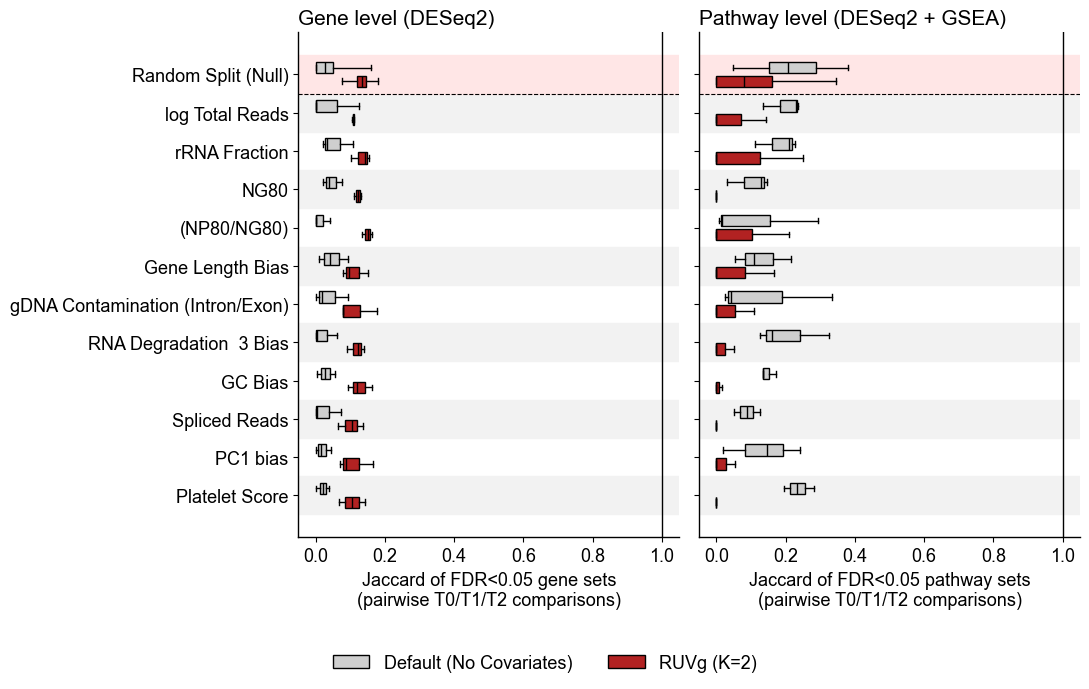

In [32]:
def pretty(a):
    if a == 'gDNA_Contamination__Intron_Exon':
        return 'gDNA Contamination (Intron/Exon)'
    if a == 'random split':
        return 'Random Split (Null)'
    return a.replace('_', ' ').replace('  Bias', ' Bias').replace('NP80 NG80', '(NP80/NG80)')

DESIGN_STYLE = {'no_covariate': dict(color="#CFCFCF"), 'ruvg_k1': dict(color="#E07B7B"),
                'ruvg_k2': dict(color="#B22222"), 'ruvg_k3': dict(color="#6E1414")}
y_order = sorted(axes, key=lambda a: g_tert[g_tert.axis == a]['jaccard'].median())

# Move 'random split' to the top by appending it at the end of the list
RANDOM_LABEL = pretty('random split')
y_categories = [pretty(a) for a in y_order] + [RANDOM_LABEL]
ypos = {c: i for i, c in enumerate(y_categories)}

def shade_rows(ax):
    for i, cat in enumerate(y_categories):
        # Apply light pink background specifically for 'random split'
        if cat == RANDOM_LABEL:
            ax.axhspan(i - 0.5, i + 0.5, color='#ffe6e6', zorder=0)
        elif i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color='#f2f2f2', zorder=0)

def draw_box(ax, vals, color, ypos_val, width=0.32):
    if vals is None or len(vals) < 2:
        return
    bp = ax.boxplot([vals], positions=[ypos_val], vert=False, widths=width, patch_artist=True,
                    whis=(0, 100), showfliers=False, zorder=3, manage_ticks=False)
                    
    for box in bp['boxes']:
        box.set_facecolor(color)
        box.set_edgecolor('black')
        box.set_linewidth(1)
        
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(1)
        
    for part in ('whiskers', 'caps'):
        for ln in bp[part]:
            ln.set_color('black')
            ln.set_linewidth(1)

def plot_panel(ax, tert, null_df, xlabel, title):
    shade_rows(ax)
    for a in y_order:
        y = pretty(a)
        for off, design in zip([0.18, -0.18], DESIGNS):
            vals = tert.loc[(tert.axis == a) & (tert.design == design), 'jaccard'].values
            draw_box(ax, vals, DESIGN_STYLE[design]['color'], ypos[y] + off, width=0.30)
            
    for off, design in zip([0.18, -0.18], DESIGNS):
        vals = null_df.loc[null_df.design == design, 'jaccard'].values
        draw_box(ax, vals, DESIGN_STYLE[design]['color'], ypos[RANDOM_LABEL] + off, width=0.30)
        
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    ax.set_yticks(range(len(y_categories)))
    ax.set_yticklabels(y_categories)
    ax.axhline(ypos[RANDOM_LABEL] - 0.5, color='black', lw=0.8, ls='--')
    
    # Add vertical line for theoretical upper bound
    ax.axvline(1.0, color='black', lw=1, ls='-', zorder=1)

fig, (axG, axP) = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)
plot_panel(axG, g_tert, g_null, 'Jaccard of FDR<0.05 gene sets\n(pairwise T0/T1/T2 comparisons)', 'Gene level (DESeq2)')
plot_panel(axP, p_tert, p_null, 'Jaccard of FDR<0.05 pathway sets\n(pairwise T0/T1/T2 comparisons)', 'Pathway level (DESeq2 + GSEA)')

# Match legend edgecolor to the actual plotted boxes
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=DESIGN_STYLE['no_covariate']['color'], 
                  edgecolor='black', label='Default (No Covariates)'),
    plt.Rectangle((0, 0), 1, 1, facecolor=DESIGN_STYLE[RUVG_PICK]['color'], 
                  edgecolor='black', label=f'RUVg (K={RUVG_PICK[-1]})'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig(config.CTRL_COMP_FIG_DIR / f'fdr_reproducibility_{RUVG_PICK}.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# significant gene/pathway COUNT per split (T0/T1/T2), cache-first
_gene_nsig_csv = config.CTRL_COMP_DIR / 'gene_fdr_nsig.csv'
if _gene_nsig_csv.exists():
    g_nsig = pd.read_csv(_gene_nsig_csv)
else:
    from compute_fdr_set_jaccard import sig_sets, STAT_DIR
    rows = []
    for tag in sorted(p.name for p in STAT_DIR.iterdir() if p.is_dir()):
        disease = 'Pancreatic Cancer' if tag.startswith('Pancreatic_Cancer') else 'Pancreatitis'
        kind = 'random' if '__null_' in tag else 'tertile'
        axis = tag.split('__', 1)[1]
        for design in DESIGNS:
            s = sig_sets(tag, design)
            if s is None:
                continue
            rows.append(dict(tag=tag, disease=disease, kind=kind, axis=axis, design=design,
                             n_sig_T0=len(s[0]), n_sig_T1=len(s[1]), n_sig_T2=len(s[2])))
    g_nsig = pd.DataFrame(rows)
    g_nsig.to_csv(_gene_nsig_csv, index=False)

g_nsig = g_nsig[g_nsig.disease == 'Pancreatic Cancer']
g_nsig_tert = g_nsig[g_nsig.kind == 'tertile']
g_nsig_null = g_nsig[g_nsig.kind == 'random']

# pathway n_sig_T0/T1/T2 already in the GSEA summary tables
p_nsig_tert = gsea_summary[gsea_summary.method.isin([f'deseq2__{d}' for d in DESIGNS])].copy()
p_nsig_tert['design'] = p_nsig_tert.method.str.replace('deseq2__', '', regex=False)
p_nsig_null = gsea_null[gsea_null.method.isin([f'deseq2__{d}' for d in DESIGNS])].copy()
p_nsig_null['design'] = p_nsig_null.method.str.replace('deseq2__', '', regex=False)

print(g_nsig_tert[['axis', 'design', 'n_sig_T0', 'n_sig_T1', 'n_sig_T2']].to_string())

                               axis        design  n_sig_T0  n_sig_T1  n_sig_T2
0                           GC_Bias  no_covariate       261       115         5
1                           GC_Bias       ruvg_k2       340       193       113
2                  Gene_Length_Bias  no_covariate       317        68        37
3                  Gene_Length_Bias       ruvg_k2       339       243       120
4                              NG80  no_covariate        60        68        38
5                              NG80       ruvg_k2       202       226       161
6                         NP80_NG80  no_covariate        31        67         0
7                         NP80_NG80       ruvg_k2       221       203       141
8                          PC1_bias  no_covariate       317       259         4
9                          PC1_bias       ruvg_k2       336       256       119
10                   Platelet_Score  no_covariate       317        21       188
11                   Platelet_Score     

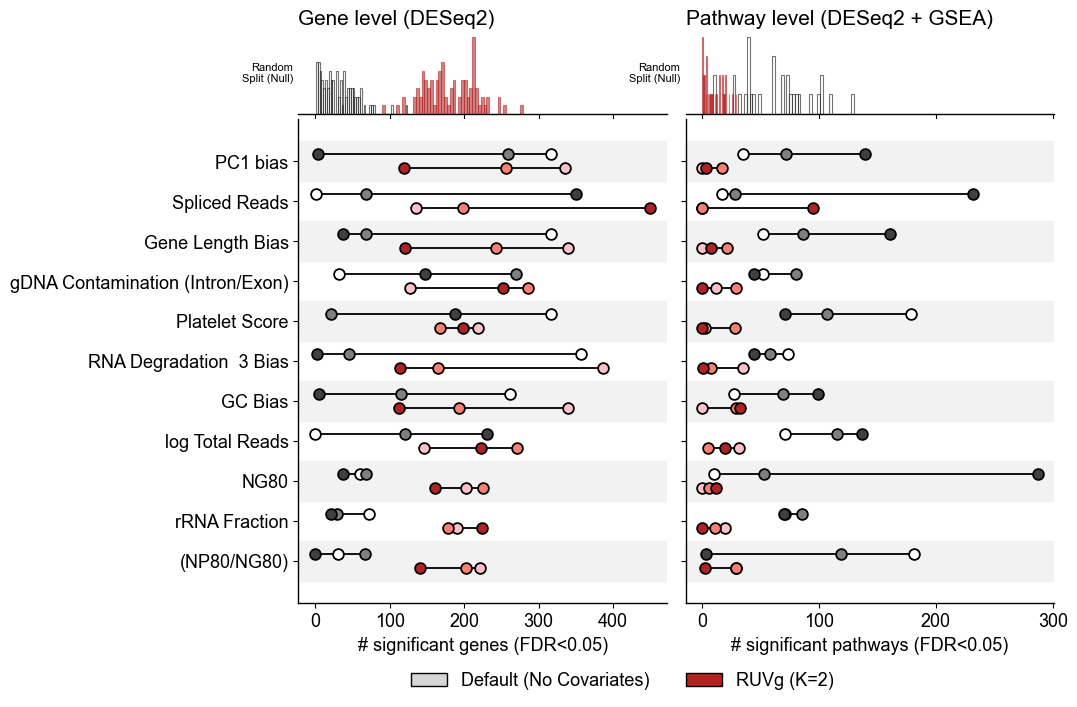

In [34]:
DESIGN_STYLE_COLORS = {
    'no_covariate': {'color': '#FFFFFF', 'edgecolor': '#000000'},
    'ruvg_k1': {'color': '#E07B7B', 'edgecolor': '#E07B7B'},
    'ruvg_k2': {'color': '#B22222', 'edgecolor': '#B22222'},
    'ruvg_k3': {'color': '#6E1414', 'edgecolor': '#6E1414'}
}
SPLIT_COLORS_NO = {'T0': '#FFFFFF', 'T1': '#808080', 'T2': '#404040'}
SPLIT_COLORS_RUVG = {'T0': '#FFC0CB', 'T1': '#FA8072', 'T2': '#B22222'}

y_order_count = sorted(axes, key=lambda a: g_nsig_tert[g_nsig_tert.axis == a][['n_sig_T0', 'n_sig_T1', 'n_sig_T2']].values.mean())
y_categories_count = [pretty(a) for a in y_order_count]
ypos_count = {c: i for i, c in enumerate(y_categories_count)}

def shade_rows_count(ax):
    for i in range(len(y_categories_count)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color='#f2f2f2', zorder=0)

def plot_count_panel(ax_null, ax_main, tert, null_df, xlabel, title, show_ylabels=True):

    for design in DESIGNS:
        vals = null_df.loc[null_df.design == design, ['n_sig_T0', 'n_sig_T1', 'n_sig_T2']].values.ravel()
        color = DESIGN_STYLE_COLORS[design]['color']
        edgecolor = DESIGN_STYLE_COLORS[design]['edgecolor']
        ax_null.hist(vals, bins=50, color=color, alpha=0.55, linewidth=0.8, edgecolor=edgecolor)

    ax_null.set_yticks([])
    ax_null.set_ylabel('Random\nSplit (Null)', fontsize=8, rotation=0, ha='right', va='center')
    ax_null.set_title(title, loc='left')
    for spine in ('top', 'right', 'left'):
        ax_null.spines[spine].set_visible(False)
    plt.setp(ax_null.get_xticklabels(), visible=False)

    shade_rows_count(ax_main)
    for a in y_order_count:
        y = pretty(a)
        for off, design in zip([0.18, -0.18], DESIGNS):
            row = tert[(tert.axis == a) & (tert.design == design)]
            if row.empty:
                continue
            vals = row[['n_sig_T0', 'n_sig_T1', 'n_sig_T2']].iloc[0]
            edgecolor = '#000000' 

            if design == 'no_covariate':
                split_colors = SPLIT_COLORS_NO
            else: 
                split_colors = SPLIT_COLORS_RUVG
            ax_main.plot([vals.min(), vals.max()], [ypos_count[y] + off] * 2, color=edgecolor, lw=1.3, zorder=1)
            
            for split, c in split_colors.items():
                ax_main.scatter(vals[f'n_sig_{split}'], ypos_count[y] + off, s=60, zorder=2,
                                facecolor=c, edgecolor=edgecolor, linewidths=1.3)
                                
    ax_main.set_xlabel(xlabel)
    ax_main.set_yticks(range(len(y_categories_count)))
    ax_main.set_yticklabels(y_categories_count)
    if not show_ylabels:
        ax_main.tick_params(labelleft=False)

fig = plt.figure(figsize=(9, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 6], hspace=0.02, wspace=0.05, left=0.14, right=0.98, top=0.88, bottom=0.12)
axNullG, axNullP = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
axG = fig.add_subplot(gs[1, 0], sharex=axNullG)
axP = fig.add_subplot(gs[1, 1], sharex=axNullP, sharey=axG)

plot_count_panel(axNullG, axG, g_nsig_tert, g_nsig_null, '# significant genes (FDR<0.05)', 'Gene level (DESeq2)')
plot_count_panel(axNullP, axP, p_nsig_tert, p_nsig_null, '# significant pathways (FDR<0.05)', 'Pathway level (DESeq2 + GSEA)', show_ylabels=False)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#D5D5D5", edgecolor='#000000', label='Default (No Covariates)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#B22222', edgecolor='#000000', label=f'RUVg (K={RUVG_PICK[-1]})')
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.05))

plt.savefig(config.CTRL_COMP_FIG_DIR / f'fdr_significant_counts_{RUVG_PICK}.png', dpi=150, bbox_inches='tight')
plt.show()